In [1]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import nltk

In [2]:
df = pd.read_csv('movie_comments.csv')

In [3]:
df.head(3)

,text,label
0,Комедия получилась доброй и с душой. Смеха был...,no_spoiler
1,"Визуально фильм очень красивый, местами просто...",no_spoiler
2,Очень качественный звук и отличные спецэффекты...,no_spoiler


In [4]:
df.shape

(5000, 2)

In [5]:
df.isnull().sum()

,0
text,0
label,0


In [6]:
df.columns

Index(['text', 'label'], dtype='object')

In [7]:
df['label'].value_counts()

,count
label,
no_spoiler,2500
spoiler,2500


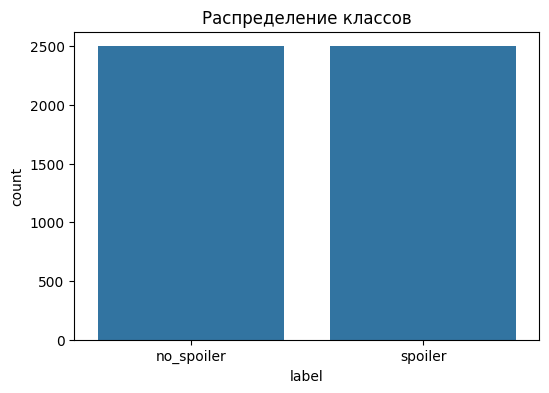

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title('Распределение классов')
plt.show()

In [9]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [10]:
rus_stopwords = stopwords.words('russian')

In [11]:
x = df['text']
y = df['label']

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [13]:
vector = CountVectorizer(stop_words=rus_stopwords)
x_train_vec = vector.fit_transform(x_train)
x_test_vec = vector.transform(x_test)

In [14]:
model_nb = MultinomialNB()
model_nb.fit(x_train_vec, y_train)
y_pred = model_nb.predict(x_test_vec)

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  no_spoiler       1.00      1.00      1.00       494
     spoiler       1.00      1.00      1.00       506

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [16]:
import joblib
joblib.dump(model_nb, 'model_nb_MovieComments.pkl')
joblib.dump(vector, 'vector_MovieComments.pkl')

['vector_MovieComments.pkl']